<a href="https://colab.research.google.com/github/Slautin/camm_hackathon/blob/k4my4r/docs%20/day_4_11072025/2025_XRD_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XRD spectra simulation

Author: Boris Slautin

powered by [pymatgen](https://pymatgen.org/)




In [ ]:
!pip install pymatgen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.1/809.1 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.1/753.1 kB 50.4 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.3-py3-none-any.whl size=43549 sha256=62770930ced154dfa4f3c928f66bfd5e9217024e0c73bda170d85cb69707c36f
  Stored in directory: /root/.cache/pip/wheels/1f/7d/e9/1ff2509f13767a55df1279744adfb757f4ab94b2cbe761f56a
Successfully built bibtexparser


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 1 Phase diagramm

=====================================

###Pb(Zr₁₋ₓTiₓ)O₃ (PZT) PHASE DIAGRAM

=====================================

This module defines the crystallographic phase of PZT as a function
of titanium composition `x` and temperature `T`. It provides an
approximate, continuous model suitable for phase-field simulations,
structure factor generation, or diffraction pattern prediction.

The main function `pzt_phase(x, T)` returns a dictionary describing:

* `phase`: qualitative name of the stable phase (cubic, rhombohedral,
  tetragonal, monoclinic, or mixed R+T)
* `symmetry`: associated space group or point group
* `parameters`: lattice constants {a,b,c,alpha,beta,gamma}, including
  optional phase fractions in the coexistence region

The function internally determines:

1. The Curie temperature `Tc(x)` separating ferroelectric and
   paraelectric regions, estimated by a polynomial fit (`Tc_fit`).
2. The morphotropic phase boundary (MPB) range between 0.45 < x < 0.52,
   which controls the transition between rhombohedral and tetragonal
   symmetries, with a monoclinic bridging phase near x ≈ 0.48.
3. Temperature- and composition-dependent lattice parameters derived
from simplified, physically consistent empirical relations.
Vegard-type linear interpolation with respect to composition is
used in the cubic and tetragonal regions to represent solid-solution
behavior, combined with first-order thermal expansion (~1×10⁻⁵/°C).

Behavior by region:

* T > Tc(x): cubic paraelectric phase (Pm-3m)
* x < 0.45: rhombohedral (R3m)
* x > 0.52: tetragonal (P4mm)
* 0.45 ≤ x ≤ 0.52 and low T: monoclinic (Cm)
* 0.45 ≤ x ≤ 0.52 and high T: mixed R+T coexistence

Supporting helper functions:

* `Tc_fit(x)`: Curie temperature (°C)
* `T_monoclinic_upper(x)`: temperature limit of monoclinic phase
* `rhombohedral_params(x, T)`: returns a, α
* `tetragonal_params(x, T)`: returns a, c
* `monoclinic_params(x, T)`: returns a, b, c, β
* `a_cubic_fit(x, T)`: returns cubic lattice constant

All geometric parameters include first-order thermal expansion (~1×10⁻⁵/°C).
These parameterizations reproduce the main experimental features of the
PZT phase diagram near room temperature and the morphotropic boundary,
providing a consistent and computationally lightweight structural model.



> Note: This is a simplified phase diagram. All parameters were derived from literature sources identified by the ChatGPT model. Some discrepancies with experimental data may remain.



In [ ]:
# ================================================================
# MAIN PHASE FUNCTION
# ================================================================

def pzt_phase(x: float, T: float):
    """
    Returns a dictionary formatted for structure / XRD simulation.

    Output keys:
      'phase'      – phase name
      'symmetry'   – space group or crystal class
      'parameters' – dict with {a,b,c,alpha,beta,gamma}
    """

    Tc = Tc_fit(x)
    if T > Tc:
        # Cubic paraelectric phase
        a = a_cubic_fit(x, T)
        return {
            "phase": "cubic",
            "symmetry": "Pm-3m",
            "parameters": {"a": a, "b": a, "c": a,
                           "alpha": 90, "beta": 90, "gamma": 90}
        }

    # Phase-field below Tc
    x_mpb_low, x_mpb_high = 0.45, 0.52

    if x < x_mpb_low:
        # Rhombohedral
        p = rhombohedral_params(x, T)
        return {
            "phase": "rhombohedral",
            "symmetry": "R3m",
            "parameters": {"a": p["a"], "b": p["a"], "c": p["a"],
                           "alpha": p["alpha"], "beta": p["alpha"], "gamma": p["alpha"]}
        }

    elif x > x_mpb_high:
        # Tetragonal
        p = tetragonal_params(x, T)
        return {
            "phase": "tetragonal",
            "symmetry": "P4mm",
            "parameters": {"a": p["a"], "b": p["a"], "c": p["c"],
                           "alpha": 90, "beta": 90, "gamma": 90}
        }

    else:
        # MPB region
        if T < T_monoclinic_upper(x):
            p = monoclinic_params(x, T)
            return {
                "phase": "monoclinic",
                "symmetry": "Cm",
                "parameters": {"a": p["a"], "b": p["b"], "c": p["c"],
                               "alpha": 90, "beta": p["beta"], "gamma": 90}
            }
        else:
            # Mixed R+T coexistence
            w_t = (x - x_mpb_low) / (x_mpb_high - x_mpb_low)
            w_r = 1 - w_t
            p_r = rhombohedral_params(x_mpb_low, T)
            p_t = tetragonal_params(x_mpb_high, T)
            return {
                "phase": "mixed R+T",
                "symmetry": "mixed",
                "parameters": {
                    "a": (p_r["a"], p_t["a"]),
                    "b": (p_r["a"], p_t["a"]),
                    "c": (p_r["a"], p_t["c"]),
                    "alpha": (p_r["alpha"], 90),
                    "beta": (p_r["alpha"], 90),
                    "gamma": (p_r["alpha"], 90),
                    "phase_fraction": {"rhombohedral": w_r, "tetragonal": w_t}
                }
            }


# ================================================================
# PARAMETER MODELS (simplified but physically consistent)
# ================================================================

def Tc_fit(x):
    """Approximate Curie temperature in °C for Pb(Zr₁₋ₓTiₓ)O₃."""
    return 300 + 200*x - 50*x**2

def T_monoclinic_upper(x):
    """Upper stability of monoclinic (MPB) phase."""
    x0, width, Tmax = 0.48, 0.04, 200
    if abs(x - x0) > width:
        return 0
    return Tmax * (1 - abs(x - x0) / width)


def rhombohedral_params(x, T):
    """
    Approximate lattice parameters for the rhombohedral region of PZT.
    Returns dict with: a, alpha (deg).
    """
    # base reference at x=0.45 (near MPB) and T=25 °C
    a_ref = 4.06   # approx pseudocubic equivalent
    alpha_ref = 89.8

    # at x=0 (Zr-rich end) assume a0 ~4.11 Å, alpha0 ~89.6°
    a0 = 4.11
    alpha0 = 89.6

    frac = x / 0.45
    a = a0 + (a_ref - a0) * frac
    alpha = alpha0 + (alpha_ref - alpha0) * frac

    # thermal expansion (≈1e-5 /°C)
    a *= (1 + 1e-5 * (T - 25))
    return {"a": a, "alpha": alpha}

def tetragonal_params(x, T):
    # assume x in [0.52, 1.0]
    a_t0 = 4.044
    c_t0 = 4.138
    # maybe for x=1 (PbTiO3) a≈3.90, c≈4.15
    a_t1 = 3.90
    c_t1 = 4.15

    frac = (x - 0.52) / (1.0 - 0.52)
    a = a_t0 + (a_t1 - a_t0)*frac
    c = c_t0 + (c_t1 - c_t0)*frac

    alpha_th = 1e-5
    a *= (1 + alpha_th*(T - 25))
    c *= (1 + alpha_th*(T - 25))
    return {"a": a, "b": a, "c": c}

def monoclinic_params(x, T):
    """Monoclinic (MPB) PZT parameters."""
    T0, x0 = 25, 0.48
    a = 5.72 + 0.05*(x - x0)
    b = 5.70 - 0.05*(x - x0)
    c = 4.14
    beta = 90.5 + 0.2*(x - x0)
    a *= 1 + 1e-5 * (T - T0)
    b *= 1 + 1e-5 * (T - T0)
    c *= 1 + 1e-5 * (T - T0)
    return {"a": a, "b": b, "c": c, "beta": beta}

def a_cubic_fit(x, T):
    """Cubic paraelectric lattice parameter (Vegard + expansion)."""
    a = 4.14 - 0.17 * x
    return a * (1 + 1.1e-5 * (T - 25))


In [ ]:
# Encode phase regions numerically over (T, x) grid using pzt_phase().
# Each unique phase name is assigned an integer key for visualization.

def ensure_key(d, key):
    if key not in d:
        d[key] = len(d)
    return d

tt = np.linspace(0, 500, 1000)
xx = np.linspace(0, 1, 1000)



TT, XX = np.meshgrid(tt, xx, indexing="ij")
phase = np.zeros_like(TT)
a = np.zeros_like(TT)

enc_phases = {}
for i in range(TT.shape[0]):
  for j in range(TT.shape[1]):
    res_dict = pzt_phase(XX[i,j], TT[i,j])
    ph = res_dict['phase']
    enc_phases = ensure_key(enc_phases, ph)

    phase[i,j] = enc_phases[ph]

    aa = res_dict['parameters']['a']

    if isinstance(aa, tuple):
      w_t = list(res_dict['parameters']['phase_fraction'].values())

      aa =(aa[0]*w_t[0] + aa[1]*w_t[1])

    a[i,j] = aa

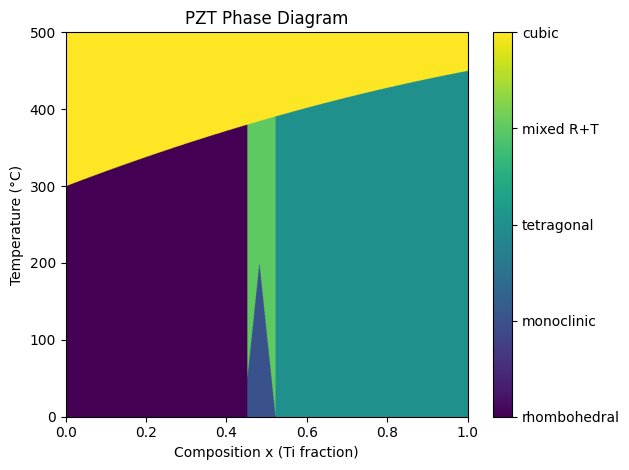

In [ ]:
im = plt.imshow(phase,
           origin='lower',
           extent=(xx.min(), xx.max(), tt.min(), tt.max()),
           aspect='auto'
           )
# create colorbar
cbar = plt.colorbar(im)

# set tick positions and labels
tick_positions = list(enc_phases.values())
tick_labels = list(enc_phases.keys())

cbar.set_ticks(tick_positions)
cbar.set_ticklabels(tick_labels)

# optionally rotate labels for readability
plt.setp(cbar.ax.get_yticklabels(), rotation=0, ha='left')

plt.xlabel("Composition x (Ti fraction)")
plt.ylabel("Temperature (°C)")
plt.title("PZT Phase Diagram")
plt.tight_layout()
plt.show()

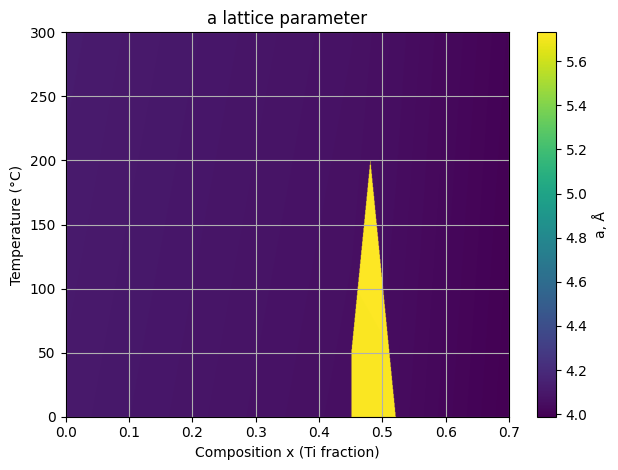

In [ ]:
#define region of interest in the Phase Diagramm
tt = np.linspace(0, 300, 1000)
xx = np.linspace(0, .7, 1000)


TT, XX = np.meshgrid(tt, xx, indexing="ij")
a = np.zeros_like(TT)

enc_phases = {}
for i in range(TT.shape[0]):
  for j in range(TT.shape[1]):
    res_dict = pzt_phase(XX[i,j], TT[i,j])
    aa = res_dict['parameters']['a']

    if isinstance(aa, tuple):
      w_t = list(res_dict['parameters']['phase_fraction'].values())
      aa =(aa[0]*w_t[0] + aa[1]*w_t[1])

    a[i,j] = aa

im = plt.imshow(a,
           origin='lower',
           extent=(xx.min(), xx.max(), tt.min(), tt.max()),
           aspect='auto',)
# create colorbar
cbar = plt.colorbar(im, label="a, Å")

plt.xlabel("Composition x (Ti fraction)")
plt.ylabel("Temperature (°C)")
plt.title("a lattice parameter")
plt.grid()
plt.tight_layout()


# 2. XRD Simulator

=====================================================

### CRYSTALBUILDER: UNIVERSAL STRUCTURE AND XRD GENERATOR

=====================================================

This class constructs crystallographic models and corresponding X-ray
diffraction (XRD) patterns from provided symmetry and lattice parameters.
It supports both single-phase and mixed-phase (e.g., MPB) systems using
pymatgen’s `Lattice` and `Structure` objects together with the
`XRDCalculator` module.

Purpose:
The class is designed to bridge phenomenological phase-field or
thermodynamic models (such as `pzt_phase`) with crystallographic
and diffraction-based observables. It enables rapid visualization
of composition–temperature-dependent structural evolution.

Key features:]

• Supports multiple crystal symmetries:
cubic, tetragonal, rhombohedral, monoclinic, orthorhombic,
hexagonal, and triclinic.

• Accepts either single-phase parameters or mixed-phase descriptions
with phase fractions (e.g., "rhombohedral" + "tetragonal").

• Generates pymatgen `Structure` objects and simulates XRD patterns
for each phase, including Gaussian broadening to approximate
instrumental effects.

Internal workflow:

1. `__init__` initializes with symmetry, parameters, and optional
   species/atomic coordinates. If `phase_fraction` is present in
   `parameters`, it automatically constructs multiple structures
   with appropriate weighting.
2. `_build_lattice()` creates a single `Lattice` instance based on
   crystal symmetry and metric tensor parameters.
3. `_build_mixed_lattices()` handles coexistence regions by building
   several lattices, each associated with its phase fraction and
   symmetry type. Parameters can be tuples or scalars.
4. `broaden_pattern()` converts discrete ("stick") XRD peaks into a
   continuous profile using Gaussian broadening with specified FWHM.
5. `get_xrd_pattern()` calculates the combined diffraction intensity
   over a 2θ grid, summing phase contributions according to their
   fractions and normalizing the total intensity.
6. `summary()` provides a compact report of all generated structures
   and associated parameters.

Typical usage:

builder = CrystalBuilder(symmetry, params)

pattern = builder.get_xrd_pattern()

plt.plot(pattern["2theta"], pattern["intensity"])

This implementation provides a compact yet extensible framework for
constructing structure-based diffraction models directly from
composition–temperature–phase diagrams, supporting both fundamental
analysis and AI-driven materials discovery workflows.


In [ ]:
import numpy as np
from pymatgen.core import Lattice, Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator

class CrystalBuilder:
    """
    Universal structure + XRD pattern generator supporting mixed phases (MPB).
    """

    def __init__(self, symmetry, parameters, species=None, coords=None):
        self.symmetry = symmetry.lower()
        self.parameters = parameters
        self.species = species or ["A", "B", "O", "O", "O"]
        self.coords = coords or [
            [0, 0, 0], [0.5, 0.5, 0.5],
            [0.5, 0.5, 0.0], [0.5, 0.0, 0.5], [0.0, 0.5, 0.5]
        ]

        # If mixed phases (e.g., MPB), store multiple structures
        if "phase_fraction" in parameters:
            self.structures = self._build_mixed_lattices()
        else:
            self.lattice = self._build_lattice()
            self.structure = Structure(self.lattice, self.species, self.coords)
            self.structures = {self.symmetry: (self.structure, 1.0)}

    # -------------------------------------------------------------
    def _build_lattice(self):
        """Build pymatgen Lattice from symmetry and parameters."""
        p = self.parameters
        sym = self.symmetry
        sg_map = {
            "p4mm": "tetragonal",
            "r3m": "rhombohedral",
            "r3c": "rhombohedral",
            "cm": "monoclinic",
            "pm-3m": "cubic"
        }
        sym = sg_map.get(sym, sym)

        if sym == "cubic":
            return Lattice.cubic(p["a"])
        elif sym == "tetragonal":
            return Lattice.tetragonal(p["a"], p["c"])
        elif sym == "rhombohedral":
            return Lattice.rhombohedral(p["a"], p.get("alpha", 89.9))
        elif sym == "monoclinic":
            return Lattice.monoclinic(p["a"], p["b"], p["c"], p.get("beta", 90.0))
        else:
            raise ValueError(f"Unknown symmetry type: {sym}")

    # -------------------------------------------------------------
    def _build_mixed_lattices(self):
        """
        Handle mixed-phase systems (e.g., MPB, solid solutions).
        Automatically detects available symmetries and constructs appropriate lattices.
        """
        p = self.parameters
        fractions = p["phase_fraction"]
        lattices = {}

        # Helper to safely extract tuple or scalar parameter
        def get_param(name, idx, default=None):
            val = p.get(name, default)
            if isinstance(val, (list, tuple)):
                return val[idx]
            return val

        # Map of symmetry → corresponding pymatgen lattice constructor
        lattice_builders = {
            "cubic": lambda i: Lattice.cubic(get_param("a", i)),
            "tetragonal": lambda i: Lattice.tetragonal(get_param("a", i), get_param("c", i)),
            "orthorhombic": lambda i: Lattice.orthorhombic(
                get_param("a", i), get_param("b", i), get_param("c", i)
            ),
            "hexagonal": lambda i: Lattice.hexagonal(get_param("a", i), get_param("c", i)),
            "rhombohedral": lambda i: Lattice.rhombohedral(
                get_param("a", i), get_param("alpha", i, 89.9)
            ),
            "monoclinic": lambda i: Lattice.monoclinic(
                get_param("a", i), get_param("b", i), get_param("c", i), get_param("beta", i, 90.0)
            ),
            "triclinic": lambda i: Lattice.from_parameters(
                get_param("a", i), get_param("b", i), get_param("c", i),
                get_param("alpha", i, 90), get_param("beta", i, 90), get_param("gamma", i, 90)
            ),
        }

        # Iterate over each phase (e.g. "rhombohedral", "tetragonal", "cubic" ...)
        for i, (phase_name, frac) in enumerate(fractions.items()):
            phase_key = phase_name.lower()
            if phase_key not in lattice_builders:
                raise ValueError(f"Unsupported symmetry: {phase_key}")

            lattice = lattice_builders[phase_key](i)
            structure = Structure(lattice, self.species, self.coords)
            lattices[phase_key] = (structure, frac)

        return lattices

    # -------------------------------------------------------------
    def broaden_pattern(self, two_theta, intensities, two_theta_range=(10, 80), step=0.01, fwhm=0.05):
        """Return a smooth diffraction pattern from stick data."""
        grid = np.arange(two_theta_range[0], two_theta_range[1], step)
        sigma = fwhm / (2*np.sqrt(2*np.log(2)))
        I = np.zeros_like(grid)
        for t, h in zip(two_theta, intensities):
            I += h * np.exp(-0.5 * ((grid - t)/sigma)**2)
        return grid, I / I.max()

    # -------------------------------------------------------------
    def get_xrd_pattern(self, wavelength="CuKa", two_theta_range=(10, 80), step=0.01, fwhm=0.1):
        """Compute XRD pattern (supports single or mixed phase)."""
        calc = XRDCalculator(wavelength=wavelength)
        tt = np.arange(two_theta_range[0], two_theta_range[1], step)
        I_total = np.zeros_like(tt)
        patterns = []
        for name, (struct, weight) in self.structures.items():
            patt = calc.get_pattern(struct)
            patterns.append(patt)
            tt_b, I_b = self.broaden_pattern(np.array(patt.x), np.array(patt.y),
                                             two_theta_range, step, fwhm)
            I_total += weight * np.interp(tt, tt_b, I_b)

        return {"2theta": tt, "intensity": I_total / I_total.max(), "components": self.structures, 'patterns': patterns}

    # -------------------------------------------------------------
    def summary(self):
        """Return parameters and structures."""
        return {"symmetry": self.symmetry, "parameters": self.parameters, "structures": self.structures}


In [ ]:
#estimate XRD spectra
x = .2
T = 400 #Celsius

phase_data = pzt_phase(x=x, T=T)
builder = CrystalBuilder(
    symmetry=phase_data["symmetry"],
    parameters=phase_data["parameters"],
    species=["Pb", {"Zr": 1-x, "Ti":x}, "O", "O", "O"]
)
pattern = builder.get_xrd_pattern( two_theta_range=(20, 60),)

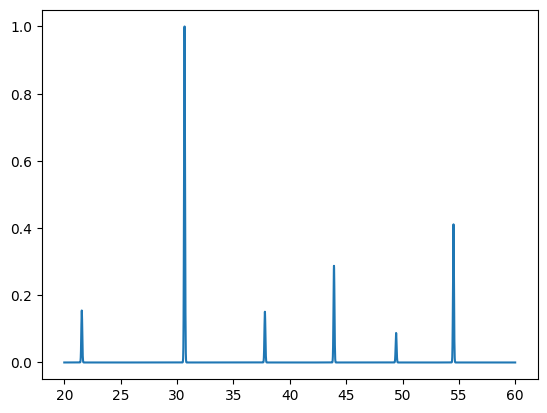

In [ ]:
#Emulated experimental diffraction spectrum with Gaussian peak broadening to mimic instrumental effects.
plt.plot(pattern['2theta'], pattern['intensity'])

In [ ]:
print('Peak position:')
print(pattern['patterns'][0].x)

print('Intensities:')
print(pattern['patterns'][0].y)

Peak position:
[21.7407353  30.85061665 31.02187187 37.91593145 38.20155686 44.31762652
 49.768022   49.99827154 54.75610251 55.07885801 55.18616096 64.27648666
 64.66674569 68.53262003 68.91054251 69.09914267 73.08219791 73.3580628
 77.11810518 77.47909765 77.65940371 81.04533029 81.75765739 85.4164514
 85.94619457 89.27670044 89.71691613 89.98103586]
Intensities:
[ 30.84269569 100.          98.59587257   7.59899109  22.31843618
  56.70206233   8.73031821   8.62458891  20.56293064  40.42070952
  20.0948888   17.95336885  17.62028592   1.88381771   3.71658891
   3.69155981  17.86332314  17.68358197   2.73318093   5.40143583
   2.68479935   3.08951655   9.07492364   2.34754284   2.32377609
  11.35837379  11.26643515  11.21284644]
